In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# important, uncomment the next line and run it if first time in a new environment as the script will pull the data files.
# !cd ..;data-exploration/get_data.sh

# prepare to load CSV files
base_url = "../data/week4/data"

# pull data files
bp_csv = Path(base_url + "/blood_pressure.csv")
hr_csv = Path(base_url + "/heart_rate.csv")
hrvm_csv = Path(base_url + "/hrv_measurements.csv")
p_csv = Path(base_url + "/participants.csv")
sd_csv = Path(base_url + "/scales_description.csv")
s_csv = Path(base_url + "/sleep.csv")
sv_csv = Path(base_url + "/surveys.csv")
wb_csv = Path(base_url + "/wearables.csv")
w_csv = Path(base_url + "/weather.csv")

git fetch https://github.com/Welltory/hrv-covid19.git master
From https://github.com/Welltory/hrv-covid19
 * branch            master     -> FETCH_HEAD
Added dir 'data/week4'


In [4]:
blood_pressure = pd.read_csv(bp_csv)
heart_rate = pd.read_csv(hr_csv)
hrv_measurements = pd.read_csv(hrvm_csv)
participants = pd.read_csv(p_csv)
scales_description = pd.read_csv(sd_csv)
sleep = pd.read_csv(s_csv)
surveys = pd.read_csv(sv_csv)
wearables = pd.read_csv(wb_csv)
weather = pd.read_csv(w_csv)

# Participants
A list of 185 study participants. Can lookup basic demographics such as gender, age, location, height, weight.

Most participants are from US and Russia.

In [5]:
# start with participants
print("Participants")
print("---------------")
print(f"Dimensions: {participants.shape}")
print(f"Data Types:\n{participants.dtypes}")
print(f"Missing Values:\n{participants.isnull().sum()}")
print(participants.head(5))

Participants
---------------
Dimensions: (185, 8)
Data Types:
user_code          object
gender             object
age_range          object
city               object
country            object
height            float64
weight            float64
symptoms_onset     object
dtype: object
Missing Values:
user_code          0
gender             0
age_range          0
city              12
country            6
height             2
weight             0
symptoms_onset    38
dtype: int64
    user_code gender age_range           city  country  height  weight  \
0  007b8190cf      m     25-34       Mandalay  Myanmar  170.18  96.162   
1  013f6d3e5b      f     18-24      São Paulo   Brazil  174.00  77.300   
2  01bad5a519      m     45-54  St Petersburg   Russia  178.00  92.000   
3  0210b20eea      f     25-34          Sochi   Russia  169.00  60.000   
4  024719e7da      f     45-54  St Petersburg   Russia  158.00  68.500   

  symptoms_onset  
0            NaN  
1      5/15/2020  
2       4/5/2020 

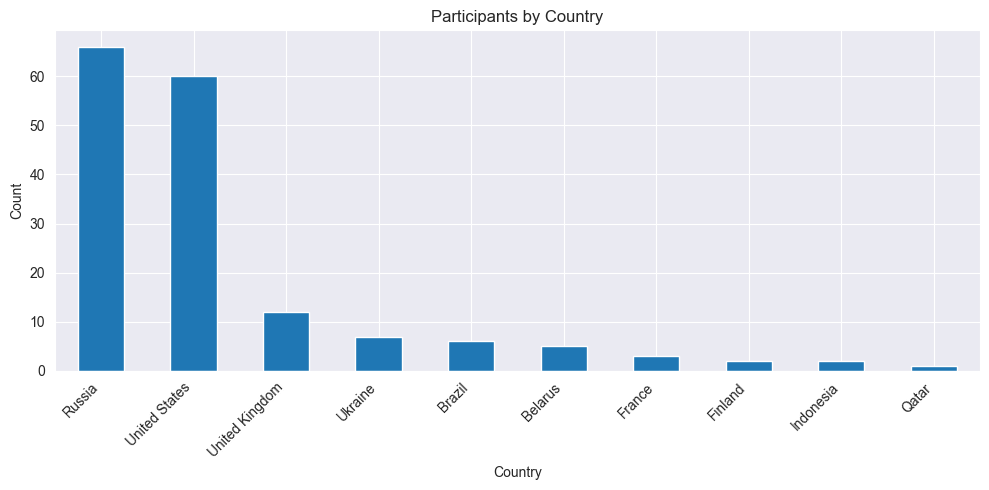

In [6]:
# Top 10 countries by participants

counts = participants["country"].value_counts().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 5))
counts.plot(kind="bar")
plt.title("Participants by Country")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Participant Weight
Looking at distribution of weights seems to indicate Finland and Qatar have "strange" distribution. Either the population are relatively uniform, or something is suspicious with the data.

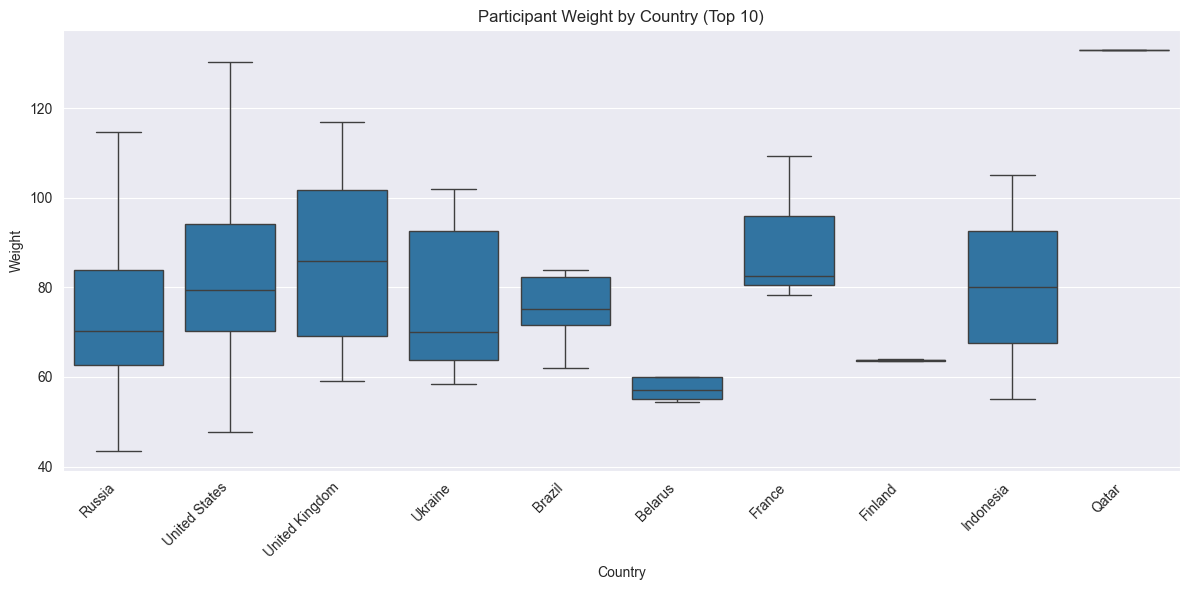

In [7]:

top_countries = counts.index.tolist()
subset = participants.loc[participants["country"].isin(top_countries), ["country", "weight"]].dropna(subset=["weight"])

plt.figure(figsize=(12, 6))
sns.boxplot(data=subset, x="country", y="weight", order=top_countries, showfliers=False)
plt.title("Participant Weight by Country (Top 10)")
plt.xlabel("Country")
plt.ylabel("Weight")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


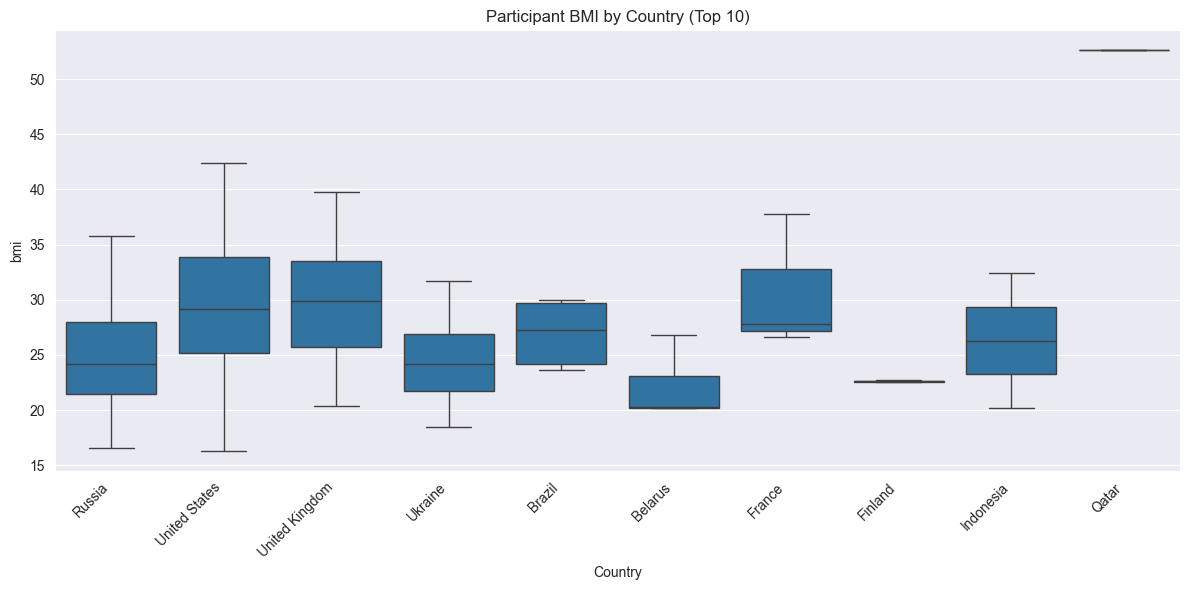

In [8]:
# Create new BMI feature for participants: BMI = weight (kg) / (height (m))^2
# Assumes 'height' is in centimeters and 'weight' is in kilograms.
height_m = pd.to_numeric(participants["height"], errors="coerce") / 100.0
weight_kg = pd.to_numeric(participants["weight"], errors="coerce")

# Avoid division by zero
height_m = height_m.replace(0, np.nan)

participants["bmi"] = (weight_kg / (height_m ** 2)).round(1)

subset = participants.loc[participants["country"].isin(top_countries), ["country", "bmi"]].dropna(subset=["bmi"])

plt.figure(figsize=(12, 6))
sns.boxplot(data=subset, x="country", y="bmi", order=top_countries, showfliers=False)
plt.title("Participant BMI by Country (Top 10)")
plt.xlabel("Country")
plt.ylabel("bmi")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



# HRV Measurements
Heart Rate Variability Measurements collected from participants (via Welltory App)
Each of the 3k+ row is a set of measurements from a point-in-time of the patient. Includes data such as the number of beats, beats interval, beat strength, and qualitative survey about mood and sleep. Many of the sleep data are blank.

In [9]:
print("HRV Measurements")
print("---------------")
print(f"Dimensions: {hrv_measurements.shape}")
print(f"Data Types:\n{hrv_measurements.dtypes}")
print(f"Missing Values:\n{hrv_measurements.isnull().sum()}")
print(hrv_measurements.head(5))

HRV Measurements
---------------
Dimensions: (3245, 22)
Data Types:
user_code                object
rr_code                  object
measurement_datetime     object
time_of_day              object
bpm                       int64
meanrr                  float64
mxdmn                   float64
sdnn                    float64
rmssd                   float64
pnn50                   float64
mode                    float64
amo                     float64
lf                      float64
hf                      float64
vlf                     float64
lfhf                    float64
total_power             float64
how_feel                  int64
how_mood                  int64
how_sleep               float64
tags                     object
rr_data                  object
dtype: object
Missing Values:
user_code                  0
rr_code                    0
measurement_datetime       0
time_of_day                0
bpm                        0
meanrr                     0
mxdmn                   

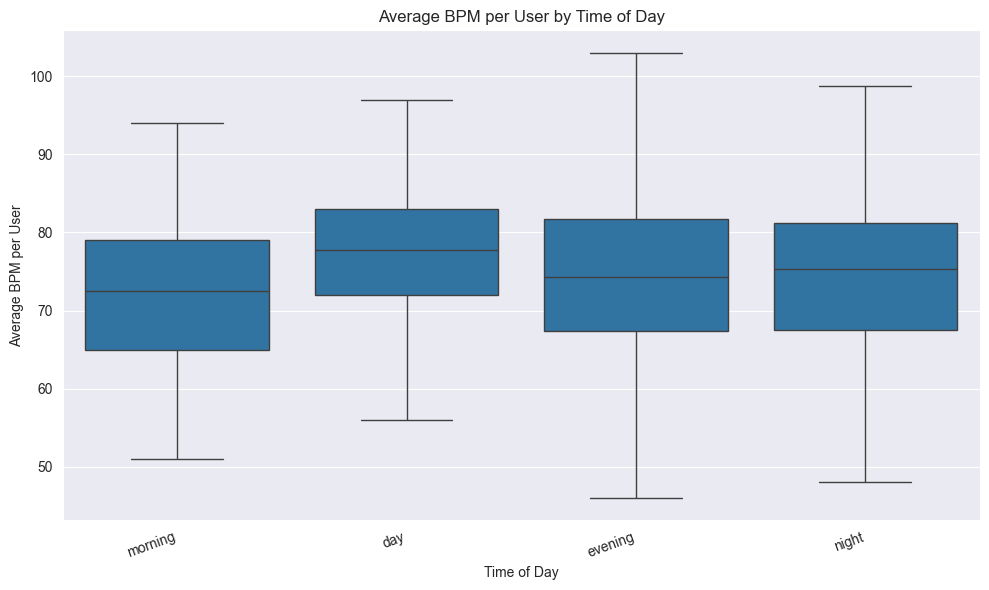

In [10]:
# Create a box plot of time_of_day vs average bpm per user using HRV measurements

# Aggregate to average BPM per user per time_of_day
agg = (
    hrv_measurements[["user_code", "time_of_day", "bpm"]]
    .dropna(subset=["time_of_day", "bpm"])
    .groupby(["user_code", "time_of_day"], as_index=False)["bpm"]
    .mean()
    .rename(columns={"bpm": "avg_bpm"})
)

# order time of day
unique_times = list(agg["time_of_day"].unique())
preferred_order = [t for t in ["morning", "day", "evening", "night"] if t in unique_times]
remaining = [t for t in unique_times if t not in preferred_order]
order = preferred_order + sorted(remaining)

plt.figure(figsize=(10, 6))
sns.boxplot(data=agg, x="time_of_day", y="avg_bpm", order=order if len(order) > 0 else None, showfliers=False)
plt.title("Average BPM per User by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Average BPM per User")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


# Blood Pressure
Measurements of blood pressure of participants.


In [11]:
print("BP Measurements")
print("---------------")
print(f"Dimensions: {blood_pressure.shape}")
print(f"Data Types:\n{blood_pressure.dtypes}")
print(f"Missing Values:\n{blood_pressure.isnull().sum()}")
print(blood_pressure.head(5))

BP Measurements
---------------
Dimensions: (721, 8)
Data Types:
user_code                    object
measurement_datetime         object
diastolic                     int64
systolic                      int64
functional_changes_index    float64
circulatory_efficiency      float64
kerdo_vegetation_index      float64
robinson_index              float64
dtype: object
Missing Values:
user_code                     0
measurement_datetime          0
diastolic                     0
systolic                      0
functional_changes_index    422
circulatory_efficiency      422
kerdo_vegetation_index      438
robinson_index              422
dtype: int64
    user_code  measurement_datetime  diastolic  systolic  \
0  01bad5a519  2020-04-29  22:33:33        100       150   
1  01bad5a519  2020-04-30  01:33:33        100       150   
2  01bad5a519  2020-04-30  09:16:38         95       140   
3  01bad5a519  2020-04-30  12:16:38         95       140   
4  01bad5a519  2020-05-01  06:58:06         80  

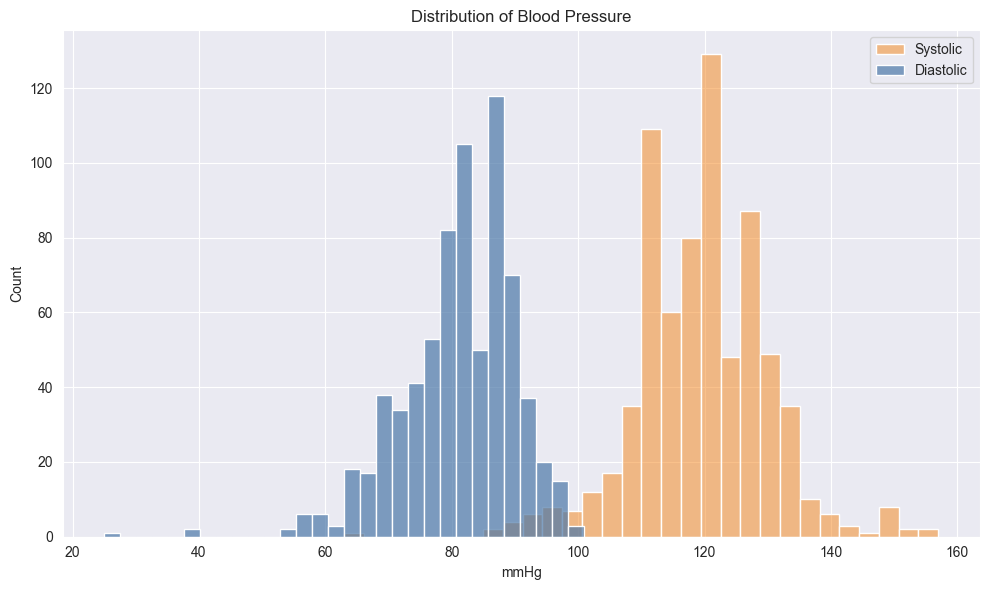

In [12]:
# Histograms of diastolic and systolic blood pressure (overlaid)
bp_vals = blood_pressure[["diastolic", "systolic"]].dropna()

plt.figure(figsize=(10, 6))
sns.histplot(bp_vals["systolic"], bins=30, color="#F58518", alpha=0.5, label="Systolic")
sns.histplot(bp_vals["diastolic"], bins=30, color="#4C78A8", alpha=0.7, label="Diastolic")  # plotted last (on top)
plt.title("Distribution of Blood Pressure")
plt.xlabel("mmHg")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()


# Heart Rate
Beats per minute data across multiple measurements (rows), with resting indicator.
There are over 500k measurements across the participants.

In [13]:

print("Heart Rate Measurements")
print("---------------")
print(f"Dimensions: {heart_rate.shape}")
print(f"Data Types:\n{heart_rate.dtypes}")
print(f"Missing Values:\n{heart_rate.isnull().sum()}")
print(heart_rate.head(5))

Heart Rate Measurements
---------------
Dimensions: (523783, 4)
Data Types:
user_code     object
datetime      object
heart_rate     int64
is_resting     int64
dtype: object
Missing Values:
user_code     0
datetime      0
heart_rate    0
is_resting    0
dtype: int64
    user_code             datetime  heart_rate  is_resting
0  007b8190cf  2020-04-26 04:49:25          70           0
1  01bad5a519  2020-04-23 06:21:03          74           0
2  01bad5a519  2020-04-23 09:46:01          82           0
3  01bad5a519  2020-04-23 14:05:06          90           0
4  01bad5a519  2020-04-24 03:41:18          72           0


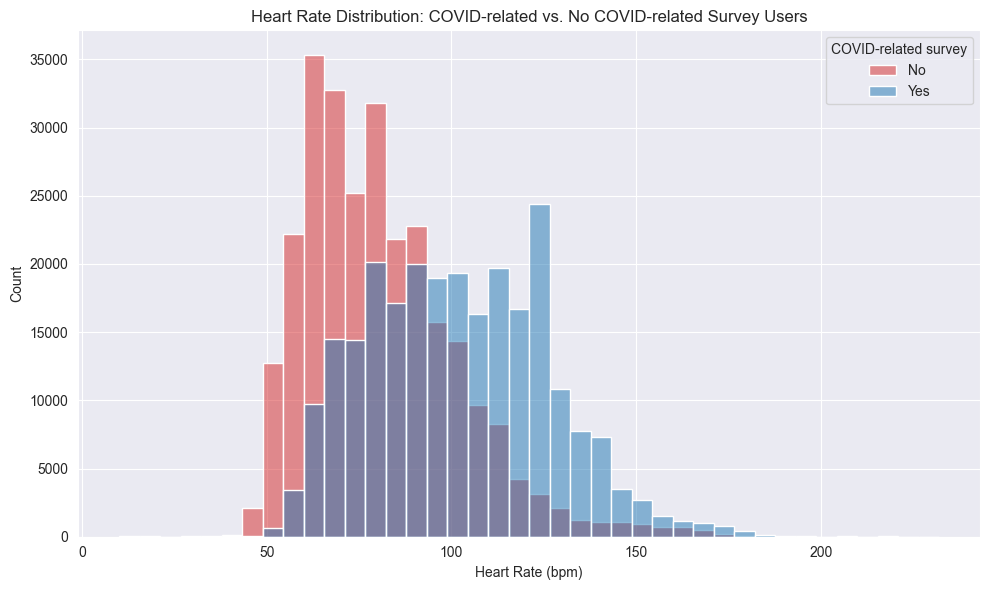

In [15]:
# Histogram of heart rate with two series: users with any COVID-related survey vs. without

# Identify users who reported any COVID-related item in surveys (value > 0). Since the survey responses are coded, just look for COVID or CORONA
covid_scales = surveys[surveys["scale"].str.contains("COVID|CORONA", case=False, na=False)]
covid_users = set(covid_scales.loc[covid_scales["value"].fillna(0) > 0, "user_code"].unique())

# Prepare heart rate data and tag COVID status
# just drop empty measurements.
hr = (
    heart_rate[["user_code", "heart_rate"]]
    .dropna(subset=["heart_rate"])
    .assign(covid=lambda df: df["user_code"].isin(covid_users))
)

plt.figure(figsize=(10, 6))
sns.histplot(
    data=hr,
    x="heart_rate",
    hue="covid",
    bins=40,
    multiple="layer",
    palette={True: "#D62728", False: "#1F77B4"},
    alpha=0.5
)
plt.title("Heart Rate Distribution: COVID-related vs. No COVID-related Survey Users")
plt.xlabel("Heart Rate (bpm)")
plt.ylabel("Count")
plt.legend(title="COVID-related survey", labels=["No", "Yes"])
plt.tight_layout()
plt.show()


In [13]:
print("Wearable measurements")
print("---------------")
print(f"Dimensions: {wearables.shape}")
print(f"Data Types:\n{wearables.dtypes}")
print(f"Missing Values:\n{wearables.isnull().sum()}")
print(wearables.head(5))

Wearable measurements
---------------
Dimensions: (3098, 18)
Data Types:
user_code                           object
day                                 object
resting_pulse                      float64
pulse_average                      float64
pulse_min                          float64
pulse_max                          float64
average_spo2_value                 float64
body_temperature_avg               float64
stand_hours_total                  float64
steps_count                        float64
distance                           float64
steps_speed                        float64
total_number_of_flights_climbed    float64
active_calories_burned             float64
basal_calories_burned              float64
total_calories_burned              float64
average_headphone_exposure         float64
average_environment_exposure       float64
dtype: object
Missing Values:
user_code                             0
day                                   0
resting_pulse                      1583
pul

# Sleep Monitoring
Data from attached sleep monitoring gadget. Features include sleep duration, hours of various cycles, and pulse during sleep. Most reliable datapoints are the start/end/duration. Most other data are blank.

In [14]:
print("Heart Rate Measurements")
print("---------------")
print(f"Dimensions: {sleep.shape}")
print(f"Data Types:\n{sleep.dtypes}")
print(f"Missing Values:\n{sleep.isnull().sum()}")
print(sleep.head(5))

Heart Rate Measurements
---------------
Dimensions: (425, 12)
Data Types:
user_code                object
day                      object
sleep_begin              object
sleep_end                object
sleep_duration          float64
sleep_awake_duration    float64
sleep_rem_duration      float64
sleep_light_duration    float64
sleep_deep_duration     float64
pulse_min               float64
pulse_max               float64
pulse_average           float64
dtype: object
Missing Values:
user_code                 0
day                       0
sleep_begin               0
sleep_end                 0
sleep_duration            0
sleep_awake_duration    416
sleep_rem_duration      418
sleep_light_duration    398
sleep_deep_duration     411
pulse_min               410
pulse_max               410
pulse_average           410
dtype: int64
    user_code         day          sleep_begin            sleep_end  \
0  0d297d2410  2019-12-31  2019-12-31 07:50:32  2019-12-31 08:45:22   
1  0d297d2410  2020-0

# Weather
Weather conditions at participant location on days with measurements. Includes basic info such as temperature, pressure, precipitation, humity, and cloud cover

In [15]:
print("Heart Rate Measurements")
print("---------------")
print(f"Dimensions: {weather.shape}")
print(f"Data Types:\n{weather.dtypes}")
print(f"Missing Values:\n{weather.isnull().sum()}")
print(weather.head(5))

Heart Rate Measurements
---------------
Dimensions: (1717, 7)
Data Types:
user_code                object
day                      object
avg_temperature_C       float64
atmospheric_pressure    float64
precip_intensity        float64
humidity                float64
clouds                  float64
dtype: object
Missing Values:
user_code               0
day                     0
avg_temperature_C       0
atmospheric_pressure    0
precip_intensity        0
humidity                0
clouds                  0
dtype: int64
    user_code         day  avg_temperature_C  atmospheric_pressure  \
0  013f6d3e5b  2020-05-22            18.0667                1017.6   
1  01bad5a519  2020-01-11            -1.2111                1016.4   
2  01bad5a519  2020-01-30             0.5056                1004.7   
3  01bad5a519  2020-04-02            -0.2444                 994.4   
4  01bad5a519  2020-04-12             5.1778                1016.1   

   precip_intensity  humidity  clouds  
0            0.0

# Survey
Results of health related survey take in app.

In [16]:
print("Heart Rate Measurements")
print("---------------")
print(f"Dimensions: {surveys.shape}")
print(f"Data Types:\n{surveys.dtypes}")
print(f"Missing Values:\n{surveys.isnull().sum()}")
print(surveys.head(5))

Heart Rate Measurements
---------------
Dimensions: (2259, 5)
Data Types:
user_code     object
scale         object
created_at    object
value          int64
text          object
dtype: object
Missing Values:
user_code     0
scale         0
created_at    0
value         0
text          0
dtype: int64
    user_code           scale  created_at  value  \
0  01bad5a519        S_CORONA  2020-04-23      2   
1  01bad5a519  S_COVID_BLUISH  2020-04-23      1   
2  01bad5a519  S_COVID_BLUISH  2020-04-25      1   
3  01bad5a519  S_COVID_BLUISH  2020-04-27      1   
4  01bad5a519  S_COVID_BLUISH  2020-04-29      1   

                                         text  
0  Symptoms are characteristic of coronavirus  
1             User isn’t experiencing symptom  
2             User isn’t experiencing symptom  
3             User isn’t experiencing symptom  
4             User isn’t experiencing symptom  


# Next steps
Because this is basic exploratory analysis, I did not go into further steps, which could include:
* deeper analysis of data anomolies such as finland and Qatar weight doesn't match expected distribution
* do some data preparations such as creating a snowflake model and saving in database for additional analysis
* prepare wide flat tables by joining multiple tables with participants table.